# Paddy Disease Detection - ResNet50 (GPU Optimized)

**Optimizations:**
- Mixed precision (FP16) for RTX 3050
- Correct augmentation order (BEFORE preprocess_input)
- tf.data with cache/prefetch
- Batch size 64 for GPU
- Gradient clipping for stable fine-tuning

In [4]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

2026-02-18 14:15:09.581495: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 14:15:09.939999: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-18 14:15:12.748325: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


In [5]:
# ============================================================================
# GPU CONFIGURATION
# ============================================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Enable memory growth to avoid OOM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    
    # Enable mixed precision for RTX 3050
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print(f"✓ GPU detected: {gpus}")
    print(f"✓ Mixed precision ENABLED")
    BATCH_SIZE = 64
else:
    print("✗ No GPU - falling back to CPU mode")
    BATCH_SIZE = 16

print(f"Batch size: {BATCH_SIZE}")

✓ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ Mixed precision ENABLED
Batch size: 64


In [6]:
# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = '../data/raw'
TRAIN_DIR = os.path.join(BASE_DIR, 'train_images')
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = 224
EPOCHS = 25
LEARNING_RATE = 1e-4
NUM_CLASSES = 10
VAL_SPLIT = 0.2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE
print("Configuration loaded!")

Configuration loaded!


## Data Pipeline

In [7]:
def get_file_paths_and_labels(data_dir):
    file_paths, labels = [], []
    class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    
    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_paths.append(os.path.join(class_dir, fname))
                labels.append(class_to_idx[class_name])
    
    return np.array(file_paths), np.array(labels), class_names

file_paths, labels, class_names = get_file_paths_and_labels(TRAIN_DIR)
print(f"Total images: {len(file_paths)}")
print(f"Classes: {class_names}")

# Stratified split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=VAL_SPLIT, stratify=labels, random_state=SEED
)
print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")

Total images: 10407
Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Train: 8325, Val: 2082


In [8]:
# ============================================================================
# AUGMENTATION (operates on [0, 255] images)
# ============================================================================
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1, fill_mode='nearest'),
    layers.RandomTranslation(0.1, 0.1, fill_mode='nearest'),
    layers.RandomZoom(0.15, fill_mode='nearest'),
    layers.RandomFlip('horizontal'),
    layers.RandomContrast(0.1),
], name='augmentation')

def load_image(file_path, label):
    """Load and resize image - NO preprocessing yet."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def apply_preprocess(img, label):
    """Apply ResNet preprocessing AFTER augmentation."""
    return preprocess_input(img), label

def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    
    # Load raw images
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    
    # Cache raw images
    ds = ds.cache()
    
    if training:
        # Augment on [0, 255] range (CORRECT ORDER)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    
    # Preprocess AFTER augmentation
    ds = ds.map(apply_preprocess, num_parallel_calls=AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels, training=False)
print("✓ Data pipelines ready")

I0000 00:00:1771404320.673495    5779 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


✓ Data pipelines ready


## Model

In [9]:
def build_model(num_classes=10, img_size=224):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False
    
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    
    # Float32 output for numerical stability with mixed precision
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    
    return keras.Model(inputs, outputs), base_model

model, base_model = build_model(NUM_CLASSES, IMG_SIZE)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable params: {sum(np.prod(v.shape) for v in model.trainable_weights):,}")
model.summary()

Trainable params: 527,626


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,850 (91.99 MB)

 Trainable params: 527,626 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

## Callbacks

In [10]:
def get_callbacks(phase):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(
            filepath=os.path.join(MODEL_DIR, f'resnet_best_{phase}.keras'),
            monitor='val_loss', save_best_only=True, verbose=1
        ),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
    ]

## Phase 1: Frozen Base

In [8]:
print("=" * 50)
print("PHASE 1: Training with frozen base")
print("=" * 50)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=get_callbacks('phase1'),
    verbose=1
)

with open(os.path.join(MODEL_DIR, 'resnet_history_phase1.pkl'), 'wb') as f:
    pickle.dump(history.history, f)
print("Phase 1 complete!")

PHASE 1: Training with frozen base
Epoch 1/25


2026-02-10 14:44:49.063781: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-02-10 14:44:56.937437: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c0404013490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-10 14:44:56.937488: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-02-10 14:44:57.495451: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-10 14:45:00.033351: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-10 14:45:01.551951: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local m

  2/131 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.1094 - loss: 3.3847 

I0000 00:00:1770714910.845970   10499 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.2048 - loss: 2.9304
Epoch 1: val_loss improved from None to 2.14002, saving model to ../models/resnet_best_phase1.keras

Epoch 1: finished saving model to ../models/resnet_best_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 636ms/step - accuracy: 0.2769 - loss: 2.6459 - val_accuracy: 0.4111 - val_loss: 2.1400 - learning_rate: 1.0000e-04
Epoch 2/25
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.4149 - loss: 2.2049
Epoch 2: val_loss improved from 2.14002 to 1.91787, saving model to ../models/resnet_best_phase1.keras

Epoch 2: finished saving model to ../models/resnet_best_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 55s 417ms/step - accuracy: 0.4326 - loss: 2.1430 - val_accuracy: 0.4827 - val_loss: 1.9179 - learning_rate: 1.0000e-04
Epoch 3/25
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.4740 - loss: 1.9862
Epoch 3: val_loss improved from 1.91787 to 1.78689, saving model to ../models/resnet_best_phase1.keras

Epo

## Phase 2: Fine-tuning

In [9]:
print("\n" + "=" * 50)
print("PHASE 2: Fine-tuning conv5_x block")
print("=" * 50)

base_model.trainable = True

# Unfreeze only conv5_x (last residual block)
FINE_TUNE_AT = 143
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print(f"Unfroze {sum(1 for l in base_model.layers if l.trainable)} layers")

# Recompile with lower LR and gradient clipping
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE/20, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=get_callbacks('phase2'),
    verbose=1
)

with open(os.path.join(MODEL_DIR, 'resnet_history_phase2.pkl'), 'wb') as f:
    pickle.dump(history_fine.history, f)
print("Phase 2 complete!")


PHASE 2: Fine-tuning conv5_x block
Unfroze 32 layers
Epoch 1/10


2026-02-10 15:09:12.952948: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=4} for conv (f16[512,3,3,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,7,7,512]{3,2,1,0}, f16[64,7,7,512]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-10 15:09:12.992622: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.039853011s
Trying algorithm eng19{k2=4} for conv (f16[512,3,3,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,7,7,512]{3,2,1,0}, f16[64,7,7,512]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operatio

131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.5758 - loss: 1.5596
Epoch 1: val_loss improved from None to 1.53397, saving model to ../models/resnet_best_phase2.keras

Epoch 1: finished saving model to ../models/resnet_best_phase2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 644ms/step - accuracy: 0.5956 - loss: 1.4876 - val_accuracy: 0.6268 - val_loss: 1.5340 - learning_rate: 5.0000e-06
Epoch 2/10
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.6523 - loss: 1.3113
Epoch 2: val_loss improved from 1.53397 to 1.46104, saving model to ../models/resnet_best_phase2.keras

Epoch 2: finished saving model to ../models/resnet_best_phase2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.6597 - loss: 1.2869 - val_accuracy: 0.6402 - val_loss: 1.4610 - learning_rate: 5.0000e-06
Epoch 3/10
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6930 - loss: 1.2200
Epoch 3: val_loss improved from 1.46104 to 1.42595, saving model to ../models/resnet_best_phase2.keras

Epo

In [10]:
model.save(os.path.join(MODEL_DIR, 'resnet_final.keras'))
print(f"Model saved!")

Model saved!


## Evaluation

In [11]:
val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)
print(f"\nValidation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

2026-02-18 14:15:52.529259: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c0414002430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-18 14:15:52.532295: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-02-18 14:15:53.538078: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-18 14:15:55.073861: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-18 14:15:56.324744: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1978', 4 bytes spill stores, 4 bytes spill loads



 2/33 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.1484 - loss: 3.1964  

I0000 00:00:1771404366.473401    5876 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 435ms/step - accuracy: 0.0768 - loss: 3.5256

Validation Accuracy: 7.68%
Validation Loss: 3.5256


In [12]:
y_pred_probs = model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_labels

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

2026-02-18 14:17:08.173922: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1913', 116 bytes spill stores, 116 bytes spill loads



32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

2026-02-18 14:17:22.034737: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1913', 124 bytes spill stores, 124 bytes spill loads



33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 369ms/step

CLASSIFICATION REPORT
                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.04      0.07      0.05        96
   bacterial_leaf_streak       0.00      0.00      0.00        76
bacterial_panicle_blight       0.05      0.78      0.10        67
                   blast       0.12      0.26      0.16       348
              brown_spot       0.00      0.00      0.00       193
              dead_heart       0.00      0.00      0.00       288
            downy_mildew       0.00      0.00      0.00       124
                   hispa       0.09      0.03      0.05       319
                  normal       0.00      0.00      0.00       353
                  tungro       0.00      0.00      0.00       218

                accuracy                           0.08      2082
               macro avg       0.03      0.11      0.04      2082
            weighted avg       0.04      0.08      0.04      2082



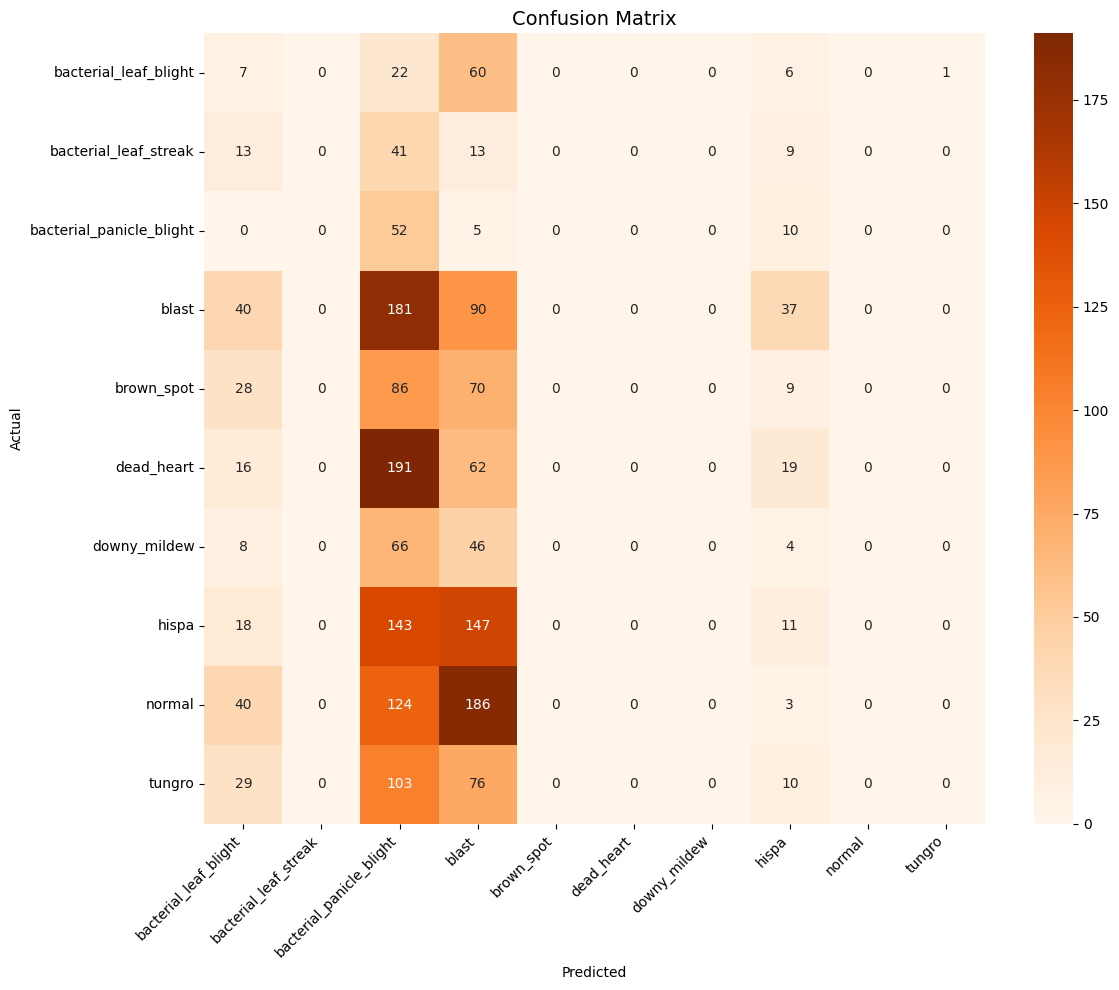

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Training History

In [1]:
def plot_history(h1, h2=None):
    if h2:
        combined = {k: h1[k] + h2[k] for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']}
        phase1_end = len(h1['accuracy'])
    else:
        combined = h1
        phase1_end = None
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(combined['accuracy'], label='Train')
    ax1.plot(combined['val_accuracy'], label='Val')
    if phase1_end:
        ax1.axvline(x=phase1_end-1, color='r', linestyle='--', label='Fine-tune start')
    ax1.set_title('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(combined['loss'], label='Train')
    ax2.plot(combined['val_loss'], label='Val')
    if phase1_end:
        ax2.axvline(x=phase1_end-1, color='r', linestyle='--', label='Fine-tune start')
    ax2.set_title('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Best val accuracy: {max(combined['val_accuracy'])*100:.2f}%")

plot_history(history.history, history_fine.history)

NameError: name 'history' is not defined